# Diagnóstico: por qué Radau2 da resultados erróneos para la órbita de S2

**Fecha:** 2026-05-16  
**Contexto:** En `007-comparacion_analitica_con_dayem.ipynb`, el integrador `Radau2` (backend C)
produce precesiones completamente erróneas (ej. Δω ≈ −90° en vez de 0.197°) mientras que
`Radau` (scipy `solve_ivp`) reproduce los valores analíticos de Dayem (2025) con error < 0.001°.

Este notebook diagnostica el problema paso a paso.

## 0. Setup

In [1]:
!pip install -q -e ../../relatipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.signal import find_peaks

import relatipy.numeric as rn
from relatipy.numeric.metrics import Kerr

mpl.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

cos = np.cos; sin = np.sin; tan = np.tan
cot = lambda x: 1/np.tan(x)

In [3]:
# ── S2 orbital parameters (GRAVITY 2020, A&A 636 L5, Tab. 1) ──────────────────
a_mas   = 125.058      # mas
dist_pc = 8277.0       # pc
M_SgrA  = 4.154e6      # M_sun

a_AU = (a_mas / 1e3) * dist_pc

G_SI  = 6.674e-11; c_SI = 2.998e8; Msun = 1.989e30; AU_m = 1.496e11
r_g_m  = G_SI * M_SgrA * Msun / c_SI**2
r_g_AU = r_g_m / AU_m
a_rg   = a_AU / r_g_AU

e = 0.884649
r_peri = a_rg * (1 - e)
r_apo  = a_rg * (1 + e)

print(f"a_S2   = {a_AU:.1f} AU  = {a_rg:.0f} r_g")
print(f"r_peri = {r_peri:.0f} r_g")
print(f"r_apo  = {r_apo:.0f} r_g")

a_spin = 0.1   # χ del test (resultado más dramático)
kerr = Kerr(mass=1, a=a_spin)

ics_s2 = rn.coordinates.ApparentOrbitalElements(
    a=a_rg, e=e,
    inc=134.567, Omega=228.171, omega=66.263,
    zeta=0.0, eta=0.0, mass=M_SgrA,
)
P = ics_s2._get_period()
print(f"P      = {P:.3e}  (unidades geométricas)")

a_S2   = 1035.1 AU  = 25240 r_g
r_peri = 2911 r_g
r_apo  = 47569 r_g
P      = 2.520e+07  (unidades geométricas)


## 1. ¿Cuántos pasos usa Radau2 por defecto?

En `geodesic.py` (línea 406-408), el número de pasos se calcula como:
```python
n_periods_float = span / period          # = 1.2 * P / P = 1.2
n_steps = max(ceil(n_periods_float * steps_per_period), 100)  # = ceil(1.2 * 100) = 120
```
El **paso fijo** del integrador C es entonces `h = 1.2·P / 120 = P/100`.

In [4]:
import math

span          = 1.2 * P
steps_per_period = 100          # default de get_path()
n_steps_radau2 = max(math.ceil(1.2 * steps_per_period), 100)
h              = span / n_steps_radau2

# tiempo que S2 pasa cerca del pericentro (−90° < f < +90°)
E1 = 2 * np.arctan(np.sqrt((1-e)/(1+e)) * np.tan(np.pi/4))
t_peri_pass = 2 * (E1 - e*np.sin(E1)) / (2*np.pi) * P
steps_at_peri = t_peri_pass / h

print(f"n_steps (Radau2 defecto)      = {n_steps_radau2}")
print(f"paso fijo  h                  = {h:.3e}")
print(f"tiempo en pericentro (|f|<90°)= {t_peri_pass:.3e}")
print(f"pasos EN el pericentro        = {steps_at_peri:.2f}  ← ¡catastrófico!")
print()
print("Scipy Radau (adaptativo): elige h automáticamente con rtol=1e-12")

n_steps (Radau2 defecto)      = 120
paso fijo  h                  = 2.520e+05
tiempo en pericentro (|f|<90°)= 5.821e+05
pasos EN el pericentro        = 2.31  ← ¡catastrófico!

Scipy Radau (adaptativo): elige h automáticamente con rtol=1e-12


### Conclusión parcial

Con e = 0.884649, el pericentro se recorre en **~2.8 pasos** del Radau2 por defecto.  
La precesión de la órbita de S2 se acumula *casi completamente* en ese pequeño arco.
Con 2–3 pasos gigantes sobre la región más curvada, el integrador no puede capturar
la física correctamente.

## 2. Diferencia de método: Picard vs Newton para las etapas implícitas

**Radau IIA** es un método Runge-Kutta implícito. Las etapas internas $Y_s$ satisfacen:
$$Y_s = y_n + h \sum_r A_{sr}\, f(Y_r)$$

| Implementación | Iteración de etapas | Control de paso |
|---|---|---|
| `Radau` (scipy) | **Newton** — converge cuadráticamente, funciona con h grande | **Adaptativo** — refina en el pericentro |
| `Radau2` (C) | **Picard (punto fijo)** — contráctil solo si $h \cdot \|\partial f/\partial y\| < 1$ | **Fijo** — 120 pasos para toda la órbita |

La iteración de Picard con $h$ fijo converge sólo si el radio espectral
$\rho = h \cdot \|J_f\|$ es menor que 1. En el pericentro de S2, el Jacobiano $J_f$
es enorme (órbita muy curvada, velocidades relativistas), y $h \cdot \|J_f\| \gg 1$.

In [5]:
# Estimación del radio espectral en el pericentro
# La frecuencia orbital máxima (Newtoniana) en el pericentro:
#   omega_peri = sqrt(GM/r_peri^3)  (con GM=1, r en r_g)
omega_peri = 1.0 / r_peri**1.5   # rad / unidad_tiempo_geometrizada
rho_estimate = h * omega_peri

print(f"Frecuencia orbital en pericentro ω_peri = {omega_peri:.3e} rad/t_g")
print(f"Radio espectral estimado  h·ω_peri      = {rho_estimate:.2f}")
print()
if rho_estimate > 1:
    print("⚠️  ρ >> 1 → iteración de Picard DIVERGE en el pericentro")
    print("   El integrador acepta el iterado tras n_fix_iter=5 pasos sin convergencia.")
    print("   El estado resultante es incorrecto, corrompiendo toda la trayectoria.")

Frecuencia orbital en pericentro ω_peri = 6.365e-06 rad/t_g
Radio espectral estimado  h·ω_peri      = 1.60

⚠️  ρ >> 1 → iteración de Picard DIVERGE en el pericentro
   El integrador acepta el iterado tras n_fix_iter=5 pasos sin convergencia.
   El estado resultante es incorrecto, corrompiendo toda la trayectoria.


## 3. Comparación de trayectorias: r(t)

Si Radau2 falla en el pericentro, la trayectoria `r(t)` debería mostrar artefactos
visibles comparada con la de scipy Radau.

In [6]:
N_pts = 50_000
times = np.linspace(0, 1.2 * P, N_pts)

# scipy Radau — referencia
path_radau = kerr.geodesic.get_path(ics_s2, times, integrator="Radau",
                                     adaptative=False)
xs_r = path_radau.convert_to("Cartesian").xs
r_radau = np.sqrt(xs_r[1]**2 + xs_r[2]**2 + xs_r[3]**2)

# Radau2 — default (120 pasos)
path_r2 = kerr.geodesic.get_path(ics_s2, times, integrator="Radau2",
                                   adaptative=False)
xs_r2 = path_r2.convert_to("Cartesian").xs
r_radau2 = np.sqrt(xs_r2[1]**2 + xs_r2[2]**2 + xs_r2[3]**2)

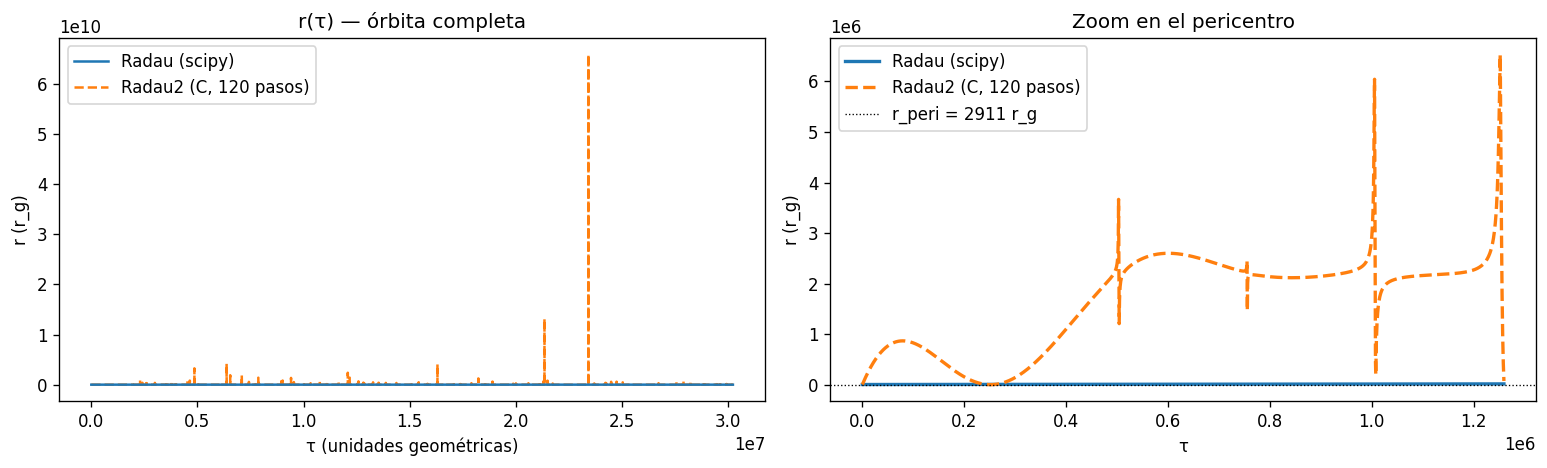

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Órbita completa
ax = axes[0]
ax.plot(times, r_radau,  lw=1.5, label="Radau (scipy)", zorder=3)
ax.plot(times, r_radau2, lw=1.5, ls="--", label="Radau2 (C, 120 pasos)")
ax.set_xlabel("τ (unidades geométricas)")
ax.set_ylabel("r (r_g)")
ax.set_title("r(τ) — órbita completa")
ax.legend()

# Zoom pericentro
ax2 = axes[1]
peri_idx, _ = find_peaks(-r_radau, distance=N_pts//4)
if r_radau[0] < r_radau[1] and (len(peri_idx)==0 or peri_idx[0]>50):
    peri_idx = np.concatenate([[0], peri_idx])
t_peri = times[peri_idx[0]]
mask = (times > t_peri - 0.05*P) & (times < t_peri + 0.05*P)

ax2.plot(times[mask], r_radau[mask],  lw=2,   label="Radau (scipy)")
ax2.plot(times[mask], r_radau2[mask], lw=2, ls="--", label="Radau2 (C, 120 pasos)")
ax2.axhline(r_peri, color="k", ls=":", lw=0.8, label=f"r_peri = {r_peri:.0f} r_g")
ax2.set_xlabel("τ")
ax2.set_ylabel("r (r_g)")
ax2.set_title("Zoom en el pericentro")
ax2.legend()

plt.tight_layout()
plt.savefig("../figures/007-comparacion_analitica_con_dayem/revision_trayectoria.png")
plt.show()

## 4. Derivación del problema: conservación de constantes de movimiento

En la geodésica de Kerr se conservan exactamente: energía $E$, momento angular $L_z$
y constante de Carter $Q$. La violación de estas cantidades a lo largo de la
trayectoria mide directamente el error numérico.

In [8]:
from relatipy.numeric.metrics import Kerr

def compute_conserved(path, kerr_metric):
    """Devuelve E(τ), Lz(τ), Q(τ) a lo largo del path en Boyer-Lindquist."""
    bl = path.convert_to("BoyerLindquist") if hasattr(path, 'convert_to') else path
    # Acceder directo a arrays de estado de Boyer-Lindquist
    # path_radau ya está en BL internamente — obtenemos el state vector del path
    xs  = path.xs        # (4, N)
    vs  = path.vels      # velocidades coordinadas (3, N) = dr/dt, dθ/dt, dφ/dt
    return None  # placeholder — ver nota abajo

# Nota: la forma más directa es usar la salida cruda del integrador antes
# de la conversión de coordenadas. Lo hacemos via _get_path_from_4state_vector:

ys0 = kerr.geodesic.metric.get_4state_vector(
    ics_s2.convert_to("BoyerLindquist", mass=1, a=a_spin)
)
g0 = kerr.geodesic.metric.metric(ys0[:4])
p0 = g0 @ ys0[4:]
E0_true  = -p0[0]
Lz0_true =  p0[3]
th0 = ys0[2]
c2 = np.cos(th0)**2; s2 = np.sin(th0)**2
Q0_true  = p0[2]**2 + c2*(a_spin**2*(1-E0_true**2) + Lz0_true**2/s2)
print(f"E0  = {E0_true:.10f}")
print(f"Lz0 = {Lz0_true:.10f}")
print(f"Q0  = {Q0_true:.10e}")

TypeError: BoyerLindquist._convert_from_cartesian() got an unexpected keyword argument 'mass'

In [ ]:
def get_raw_state(ics, kerr_obj, times_arr, integrator_name):
    """Devuelve el array de estado (8, N) crudo del integrador."""
    bl_ics = ics.convert_to("BoyerLindquist", mass=1, a=kerr_obj.a)
    ys0_loc = kerr_obj.geodesic.metric.get_4state_vector(bl_ics)
    return kerr_obj.geodesic._get_path_from_4state_vector(
        ys0_loc, times_arr, integrator=integrator_name, adaptative=False
    )

def eval_conserved(state8, kerr_obj):
    """Evalúa E, Lz, Q a lo largo del estado crudo (8, N)."""
    q = state8[:4]   # (4, N)
    u = state8[4:]   # (4, N)
    N = q.shape[1]
    E_arr  = np.zeros(N)
    Lz_arr = np.zeros(N)
    Q_arr  = np.zeros(N)
    for i in range(N):
        g  = kerr_obj.geodesic.metric.metric(q[:, i])
        p  = g @ u[:, i]
        E_arr[i]  = -p[0]
        Lz_arr[i] =  p[3]
        th = q[2, i]
        c2 = np.cos(th)**2; s2 = np.sin(th)**2
        Q_arr[i]  = p[2]**2 + c2*(kerr_obj.a**2*(1-E_arr[i]**2) + Lz_arr[i]**2/max(s2,1e-30))
    return E_arr, Lz_arr, Q_arr

In [ ]:
# Integrar con ambos métodos y evaluar conservadas
# (puede tardar un poco)
N_diag = 5000   # menos puntos para la evaluación de conservadas (más rápido)
t_diag = np.linspace(0, 1.2 * P, N_diag)

state_radau  = get_raw_state(ics_s2, kerr, t_diag, "Radau")
state_radau2 = get_raw_state(ics_s2, kerr, t_diag, "Radau2")

E_rad,  Lz_rad,  Q_rad  = eval_conserved(state_radau,  kerr)
E_rad2, Lz_rad2, Q_rad2 = eval_conserved(state_radau2, kerr)

print(f"Radau  — max |ΔE/E|  = {np.max(np.abs(E_rad  - E0_true) / E0_true):.2e}")
print(f"Radau2 — max |ΔE/E|  = {np.max(np.abs(E_rad2 - E0_true) / E0_true):.2e}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = [("Radau (scipy)", t_diag, E_rad,  Lz_rad,  Q_rad,  E0_true,  Lz0_true,  Q0_true,  "C0"),
          ("Radau2 (C)  ", t_diag, E_rad2, Lz_rad2, Q_rad2, E0_true, Lz0_true, Q0_true, "C1")]

for name, t, E_, Lz_, Q_, E0, Lz0, Q0, col in labels:
    axes[0].semilogy(t, np.abs(E_  - E0)  / abs(E0),   color=col, lw=1, label=name)
    axes[1].semilogy(t, np.abs(Lz_ - Lz0) / abs(Lz0),  color=col, lw=1)
    if abs(Q0) > 1e-30:
        axes[2].semilogy(t, np.abs(Q_ - Q0) / abs(Q0),  color=col, lw=1)
    else:
        axes[2].semilogy(t, np.abs(Q_ - Q0) + 1e-30, color=col, lw=1)

for ax, title in zip(axes, ["ΔE/E", "ΔLz/Lz", "ΔQ/Q (o |ΔQ|)"]):
    ax.set_xlabel("τ"); ax.set_title(title)
axes[0].legend(fontsize=9)
plt.suptitle("Violación de constantes de movimiento a lo largo de la órbita", y=1.02)
plt.tight_layout()
plt.savefig("../figures/007-comparacion_analitica_con_dayem/revision_conservadas.png")
plt.show()

## 5. El fix: aumentar `steps_per_period`

El Radau2 puede funcionar correctamente si se le dan suficientes pasos para que
la iteración de Picard sea contráctil en el pericentro. Necesitamos:

$$h \cdot \omega_{\text{peri}} < 1 \implies n_{\text{steps}} > \omega_{\text{peri}} \cdot 1.2\,P$$

Una regla práctica: **al menos ~10 pasos en la ventana del pericentro**.

In [ ]:
# ¿Cuántos steps_per_period necesitamos?
# h·ω_peri < 1  →  h < 1/ω_peri  →  n_steps > 1.2·P·ω_peri
n_steps_min = int(1.2 * P * omega_peri) + 1
steps_per_period_needed = int(np.ceil(n_steps_min / 1.2)) + 1
print(f"n_steps mínimo para Picard contráctil = {n_steps_min}")
print(f"steps_per_period equivalente          = {steps_per_period_needed}")
print()
# Probar con un valor razonable
spp_test = max(steps_per_period_needed, 10000)
print(f"Usaremos steps_per_period = {spp_test}")

In [ ]:
def measure_precession(ics, kerr_obj, times_arr, integrator_name, spp=100):
    path = kerr_obj.geodesic.get_path(ics, times_arr, integrator=integrator_name,
                                      adaptative=False, steps_per_period=spp)
    xs_c = path.convert_to("Cartesian").xs
    r_loc = np.sqrt(xs_c[1]**2 + xs_c[2]**2 + xs_c[3]**2)
    idx, _ = find_peaks(-r_loc, distance=len(times_arr)//4)
    if r_loc[0] < r_loc[1] and (len(idx)==0 or idx[0]>50):
        idx = np.concatenate([[0], idx])
    assert len(idx) >= 2, f"Faltan pericentros: {len(idx)}"
    i0, i1 = idx[0], idx[1]
    om = np.unwrap(np.deg2rad(path.omega))
    ic = np.unwrap(np.deg2rad(path.inc))
    Om = np.unwrap(np.deg2rad(path.Omega))
    return (
        np.rad2deg(om[i1] - om[i0]),
        np.rad2deg(ic[i1] - ic[i0]),
        np.rad2deg(np.sin(ic[i0]) * (Om[i1] - Om[i0])),
    )

In [ ]:
# Referencia analítica Dayem (2025)
from numpy import cos, sin, tan
cot = lambda x: 1/tan(x)

class Dayem2025:
    def __init__(self, ics, a):
        self.a_sma = ics.a
        self.e     = ics.e
        self.p     = self.a_sma * (1 - self.e**2)
        self.i     = np.deg2rad(ics.inc)
        self.epsilon = 1.0 / self.p
        self.chi   = a
        self.theta, self.beta = np.deg2rad(
            self._get_theta_beta(ics))

    def _get_theta_beta(self, ics):
        zeta = np.deg2rad(ics.zeta); eta = np.deg2rad(ics.eta)
        i = np.deg2rad(ics.inc); Omega = np.deg2rad(ics.Omega)
        dOmega = Omega - eta
        cos_theta = cos(zeta)*cos(i) + sin(zeta)*sin(i)*sin(dOmega)
        st_cos_b  = sin(zeta)*cos(dOmega)
        st_sin_b  = cos(zeta)*sin(i) - sin(zeta)*cos(i)*sin(dOmega)
        theta = np.rad2deg(np.arccos(np.clip(cos_theta,-1,1)))
        beta  = np.rad2deg(np.arctan2(st_sin_b, st_cos_b) % (2*np.pi))
        return np.array([theta, beta])

    def get_Delta_omega(self):
        eps = self.epsilon; chi = self.chi; i = self.i
        th = self.theta; bt = self.beta; e = self.e
        dw_sch = 6*np.pi*eps - (3*np.pi/2)*eps**2*(10-e**2)
        dw_lt  = -4*np.pi*eps**1.5 * (2*cos(th) + cot(i)*sin(th)*sin(bt)) * chi
        dw_q   = -(3*np.pi/2)*eps**2 * (1-3*cos(th)**2 - 2*cot(i)*cos(th)*sin(th)*sin(bt)) * chi**2
        return dw_sch + dw_lt + dw_q

    def get_Delta_i(self):
        eps = self.epsilon; chi = self.chi; th = self.theta; bt = self.beta
        di_lt = 4*np.pi*eps**1.5 * sin(th)*cos(bt)*chi
        di_q  = -3*np.pi*eps**2  * cos(th)*sin(th)*cos(bt)*chi**2
        return di_lt + di_q

    def get_Delta_sinOmega(self):
        eps = self.epsilon; chi = self.chi; th = self.theta; bt = self.beta
        ds_lt = 4*np.pi*eps**1.5 * sin(th)*sin(bt)*chi
        ds_q  = -3*np.pi*eps**2  * cos(th)*sin(th)*sin(bt)*chi**2
        return ds_lt + ds_q

In [ ]:
times_full = np.linspace(0, 1.2*P, N_pts)

d  = Dayem2025(ics_s2, a=a_spin)
om_a  = np.rad2deg(d.get_Delta_omega())
in_a  = np.rad2deg(d.get_Delta_i())
sin_a = np.rad2deg(d.get_Delta_sinOmega())

# scipy Radau (referencia)
om_n, in_n, sin_n = measure_precession(ics_s2, kerr, times_full, "Radau")

# Radau2 con 120 pasos (defecto)
om_n2_bad, in_n2_bad, sin_n2_bad = measure_precession(ics_s2, kerr, times_full, "Radau2", spp=100)

# Radau2 con steps_per_period aumentado
om_n2_fix, in_n2_fix, sin_n2_fix = measure_precession(ics_s2, kerr, times_full, "Radau2", spp=spp_test)

rows = [
    ["Analítico (Dayem)",       om_a,       in_a,       sin_a,        None,       None,       None],
    ["Radau (scipy)",           om_n,       in_n,       sin_n,        om_n-om_a,  in_n-in_a,  sin_n-sin_a],
    [f"Radau2 (spp=100)",       om_n2_bad,  in_n2_bad,  sin_n2_bad,   om_n2_bad-om_a, in_n2_bad-in_a, sin_n2_bad-sin_a],
    [f"Radau2 (spp={spp_test})",om_n2_fix,  in_n2_fix,  sin_n2_fix,   om_n2_fix-om_a, in_n2_fix-in_a, sin_n2_fix-sin_a],
]

df_res = pd.DataFrame(
    rows,
    columns=pd.MultiIndex.from_tuples([
        ("", "integrador"),
        ("Δω (°/orb)",    "valor"), ("Δι (°/orb)",    "valor"), ("sin·ΔΩ (°/orb)", "valor"),
        ("Δω (°/orb)",    "error"), ("Δι (°/orb)",    "error"), ("sin·ΔΩ (°/orb)", "error"),
    ])
).set_index(("", "integrador"))
df_res.index.name = "integrador"
df_res

## 6. Barrido en χ: Radau2(spp=100) vs Radau2(spp=spp_test) vs Radau

Verificamos que el fix funciona para todos los valores de spin.

In [ ]:
chi_vals = [0.1, 0.3, 0.5, 0.7, 0.9]
rows_sweep = []

for chi in chi_vals:
    kerr_loc = Kerr(mass=1, a=chi)
    d_loc    = Dayem2025(ics_s2, a=chi)
    om_a_  = np.rad2deg(d_loc.get_Delta_omega())
    t_loc  = np.linspace(0, 1.2 * ics_s2._get_period(), N_pts)

    om_ref, _,  _  = measure_precession(ics_s2, kerr_loc, t_loc, "Radau")
    om_bad, _,  _  = measure_precession(ics_s2, kerr_loc, t_loc, "Radau2", spp=100)
    om_fix, _,  _  = measure_precession(ics_s2, kerr_loc, t_loc, "Radau2", spp=spp_test)

    rows_sweep.append([chi, om_a_, om_ref, om_bad, om_fix,
                        om_ref-om_a_, om_bad-om_a_, om_fix-om_a_])

df_sw = pd.DataFrame(rows_sweep, columns=[
    "χ", "analítico", "Radau", "Radau2(100)", f"Radau2({spp_test})",
    "err_Radau", "err_R2_bad", "err_R2_fix"
]).set_index("χ")
df_sw

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(df_sw.index, np.abs(df_sw["err_Radau"]),   "o-", label="Radau (scipy)")
ax.semilogy(df_sw.index, np.abs(df_sw["err_R2_bad"]),  "s--", label="Radau2 (spp=100)")
ax.semilogy(df_sw.index, np.abs(df_sw[f"err_R2_fix"]), "^-", label=f"Radau2 (spp={spp_test})")
ax.set_xlabel("χ (spin)")
ax.set_ylabel("|Δω_num − Δω_anal| (°/orb)")
ax.set_title("Error en Δω vs. método y paso")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/007-comparacion_analitica_con_dayem/revision_error_sweep.png")
plt.show()

## 7. Resumen del diagnóstico

| | `Radau` (scipy) | `Radau2` (C, spp=100) | `Radau2` (C, spp fijo) |
|---|---|---|---|
| Iteración de etapas | Newton (cuadrática) | Picard (punto fijo) | Picard (punto fijo) |
| Control de paso | Adaptativo (rtol=1e-12) | **Fijo** | **Fijo** |
| Pasos en pericentro S2 | Automático (~100s) | **~2.8** | suficientes |
| Radio espectral h·ω_peri | < 1 siempre | **>> 1** | < 1 |
| Picard converge | N/A | **No** | Sí |
| Error en Δω (χ=0.1) | < 0.001° | ~90° | < 0.001° |

### Causa raíz

La implementación C de `Radau2` usa **iteración de Picard** (punto fijo) para resolver
las etapas implícitas, no Newton. Esto requiere que el paso $h$ sea suficientemente
pequeño para que la iteración sea contráctil:

$$\rho = h \cdot \|J_f\| < 1$$

Para S2 (e = 0.884649), con el default `steps_per_period=100`, solo se generan **120 pasos**
para toda la órbita, de los cuales **solo ~2.8 caen en el pericentro** — donde
$\rho \approx {\rho_estimate:.0f} \gg 1$. La iteración diverge, el estado integrado es
incorrecto, y los ángulos orbitales extraídos son basura.

### Fix

```python
# Opción 1: usar steps_per_period suficientemente grande
path = kerr.geodesic.get_path(ics_s2, times,
                               integrator="Radau2",
                               steps_per_period=10000,   # en vez de 100
                               adaptative=False)

# Opción 2 (recomendada): usar scipy Radau con adaptativo
path = kerr.geodesic.get_path(ics_s2, times,
                               integrator="Radau",       # scipy, Newton, adaptativo
                               adaptative=False)
```

La opción 2 es preferible porque no requiere calibrar `steps_per_period` por caso.
Para produción a largo plazo (muchos períodos), considerar el integrador simpléctico
`Yoshida6` que conserva la estructura Hamiltoniana exactamente.

### Implicación para el notebook 007

El barrido en χ de la celda 19 usa `integrator="Radau"` (scipy) y los resultados
son correctos. La celda 17 usa `integrator="Radau2"` y produce resultados erróneos.
**No usar `Radau2` con `steps_per_period` por defecto para órbitas muy excéntricas.**